# Convolutional Neural Network
___

Convolutional Neural Network (CNN) is a type of artificial neural network commonly used in computer vision and image recognition tasks. It uses convolutional layers to process and analyze input data, such as images, and generate output predictions through multiple layers of filters, pooling operations and non-linear activation functions. The architecture of a CNN enables it to automatically and adaptively learn spatial hierarchies of features from input data, making it effective for tasks such as object recognition and image classification.<br>
![CNN.webp](https://miro.medium.com/max/1400/1*z7hd8FZeI_eodazwIapvAw.webp)
<br>In simple word what CNN does is, it extract the feature of image and convert it into lower dimension without loosing its characteristics.<br>

 ### Edge Detection
 Every image has vertical and horizontal edges which actually combining to form a image. Convolution operation is used with some filters for detecting edges. Suppose you have gray scale image with dimension 6 x 6 and filter of dimension 3 x 3(say). When 6 x 6 grey scale image convolve with 3 x 3 filter, we get 4 x 4 image. First of all 3 x 3 filter matrix get multiplied with first 3 x 3 size of our grey scale image, then we shift one column right up to end , after that we shift one row and so on.


![filter.webp](attachment:filter.webp)
Filter is hyperparameter which can contribute in accuracy of model by choosing appropriate size of filter.
Filter is also called as **kernel**.


![filter_motion.gif](attachment:filter_motion.gif)

### Stride and Padding
Stride denotes how many steps we are moving in each steps in convolution.By default it is one. We can change the step size as per our need.<br><br>
![stride.gif](attachment:stride.gif)

### Padding

Padding is applied to address spatial dimension reduction in size. It involves adding zero-valued elements around the input data before it is convolved with the filters. The number of zero-valued elements added is referred to as the padding size. By adding padding, the spatial dimensions of the input data can be preserved or increased, allowing the CNN to capture more information from the input data and making it easier to detect fine details and patterns.
<br>
There Two types of padding:
1. Valid(Default) - no padding
2. Same - Adds padding on both side to input data
<br>

![padding.gif](attachment:padding.gif)


## Layers
> <h3>Convo Layer (Convolution + ReLU)</h3> <br>
Convo layer is sometimes called feature extractor layer because features of the image are get extracted within this layer. First of all, a part of image is connected to Convo layer to perform convolution operation as we saw earlier and calculating the dot product between receptive field(it is a local region of the input image that has the same size as that of filter) and the filter. Result of the operation is single integer of the output volume. Then we slide the filter over the next receptive field of the same input image by a Stride and do the same operation again. We will repeat the same process again and again until we go through the whole image. The output will be the input for the next layer.<br>
It contains ReLU Function

><h3>Pooling Layer</h3><br>
Pooling layer is used to reduce the spatial volume of input image after convolution. It is used between two convolution layer. If we apply FC after Convo layer without applying pooling or max pooling, then it will be computationally expensive and we don’t want it. So, the max pooling is only way to reduce the spatial volume of input image. In the above example, we have applied max pooling in single depth slice with Stride of 2. You can observe the 4 x 4 dimension input is reduce to 2 x 2 dimension.<br>

![pooling.webp](https://miro.medium.com/max/1400/1*Ekm4QJ1rHE-bJbQllBWLPA.webp)
<br>

> <h3>Dense / Fully Connected Layer</h3><br>
Fully connected layer involves weights, biases, and neurons. It connects neurons in one layer to neurons in another layer. It is used to classify images between different category by training.

___

Let's Study CNN with following Example: <br>
In this Example We are going to build a CNN model which will Classify the Images. <br>
### CIFAR-10 Photo Classification Dataset
CIFAR is an acronym that stands for the Canadian Institute For Advanced Research and the [CIFAR-10 dataset](https://en.wikipedia.org/wiki/CIFAR-10) was developed along with the CIFAR-100 dataset by researchers at the CIFAR institute.

The dataset is comprised of 60,000 32×32 pixel color photographs of objects from 10 classes, such as frogs, birds, cats, ships, etc. The class labels and their standard associated integer values are listed below.
<br>
0: airplane<br>
1: automobile<br>
2: bird<br>
3: cat<br>
4: deer<br>
5: dog<br>
6: frog<br>
7: horse<br>
8: ship<br>
9: truck<br>

![dataset_img.webp](https://3065708918-files.gitbook.io/~/files/v0/b/gitbook-legacy-files/o/assets%2F-LRrOFNeUGLZef_2NLZ0%2F-LeEJi2MCK6d2wToNmIy%2F-LeENgJqZAzBJi8PRELl%2Fcifar10.png?alt=media&token=bee1e40d-b4f6-4f46-a835-43d3f1223166)
<br>
These are very small images, much smaller than a typical photograph, and the dataset was intended for computer vision research.
<br>
CIFAR-10 is a well-understood dataset and widely used for benchmarking computer vision algorithms in the field of machine learning. The problem is “solved.” It is relatively straightforward to achieve 80% classification accuracy.

Let's start by simply importing basic Libraries

In [1]:
# importing basic Library
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import datasets, layers, models
import matplotlib.pyplot as plt
import PIL
import warnings
warnings.filterwarnings("ignore")

if above libraries are not installed the you can install by simply using `pip install [library name]` command

### Loading Dataset
```python
datasets.cifar10.load_data()
```
returns two sections of data, one part for training the model and another for testing the model

In [2]:
# downloading dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

from above we can observe that x_train has 4 dimensional input data
1. 50000 - Number of training data elements(images)
2. 32 x 32 x 3 - represents matrix data of each element where 3(last dimension represent <mark>RGB</mark>)

Example:

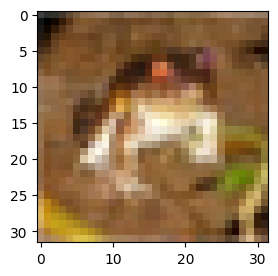

In [4]:
plt.figure(figsize = (3, 3))
plt.imshow(x_train[0])

In [5]:
y_train.shape

(50000, 1)

**y_train** is 2D array.
We have to reshape the dimension of y_train to 1D array for training purpose.

In [6]:
# reshape the y_train to 1D array
y_train = y_train.reshape(-1,)

In [7]:
class_length = len(np.unique(y_train))

Let us create the list of all the categories

In [8]:
# y_train Labels
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [9]:
# function to plot the image and its class
def show_image(x, y, index):
    plt.figure(figsize= (3, 3))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]], size=20)


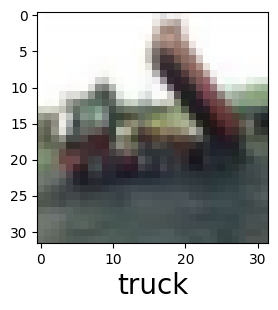

In [10]:
show_image(x_train,y_train, 2)

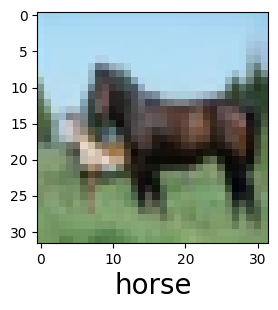

In [11]:
show_image(x_train,y_train, 12)

### Normalization
Input data can be normalize by simply dividing input data by `255`.<br>
<font color=red>Note: You have to normalize test data too.</font>

In [12]:
x_train = x_train / 255
x_test = x_test / 255

In [13]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

# model
![model.webp](https://miro.medium.com/max/1400/1*_p1DwmIPQU_gAiB197PBMQ.webp)
<br>Here, I've added 3 Convolutional `Conv2D` and MaxPooling `MaxPooling2D` layer with `filter size = 32` and `kernel size = (3, 3)`.
You can add as many as possible convolutional layers for freature extraction as per your convenience.
<br><br>
Extracted features are then converted to 1D array using `Flatten()` which will act as an input for dense layer.
I've used `ReLU` activation function in first dense layer and `Softmax` activation function in output layer.

In [14]:
cnn = keras.Sequential([

    # cnn
    layers.Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    # dense
    layers.Flatten(),
    layers.Dense(120, activation = 'relu'),
    layers.Dense(class_length, activation = 'softmax')
])

In [15]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        61,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,162 (320.95 KB)

 Trainable params: 82,162 (320.95 KB)

 Non-trainable params: 0 (0.00 B)

CNN model is optimized by `adam` optimizer and `sparse_categorical_crossentropy` as a loss function because we are directly using the categorical number `[0,1,2,...,9]` representing classes instead of one hot encoding.<br>
<font color=green>Try Different optimizers</font> [Tensorflow.keras.optimizers](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)

In [16]:
cnn.compile(optimizer = 'Adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

### Training Model
I've used only 10 Epochs. You can play with it and check accuracy.

In [17]:
history = cnn.fit(x_train, y_train, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.3841 - loss: 1.6799
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.5968 - loss: 1.1297
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.6650 - loss: 0.9519
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.7000 - loss: 0.8474
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 31ms/step - accuracy: 0.7255 - loss: 0.7791
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.7489 - loss: 0.7126
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.7706 - loss: 0.6577
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.7862 - loss: 0.6094
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 30ms/step - accuracy: 0.7981 - loss: 0.5716
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.8113 - loss: 0.5314


In [18]:
cnn.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7354 - loss: 0.8074


[0.8108195662498474, 0.7335000038146973]

Loss is `0.839`<br>
Accuracy is `0.726`<br>
You can try to get more accuracy by fine tunning the model.


### Test
We have to convert `y_test` from `2D` array to `1D` array for computation same as we have done for `x_train`.

In [19]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

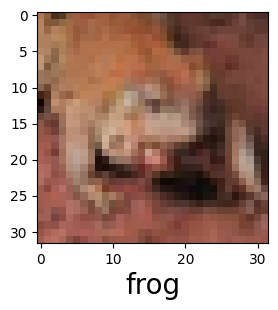

In [20]:
show_image(x_test, y_test, 5)

In [34]:
history.history

{'accuracy': [0.4729200005531311,
  0.6131799817085266,
  0.667140007019043,
  0.7009400129318237,
  0.7259200215339661,
  0.7491999864578247,
  0.7676399946212769,
  0.7813199758529663,
  0.7943199872970581,
  0.8057799935340881],
 'loss': [1.4551982879638672,
  1.0912013053894043,
  0.9463089108467102,
  0.848511278629303,
  0.7756097912788391,
  0.7125027179718018,
  0.6660865545272827,
  0.6221476793289185,
  0.5836897492408752,
  0.5496078133583069]}

In [22]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

[]

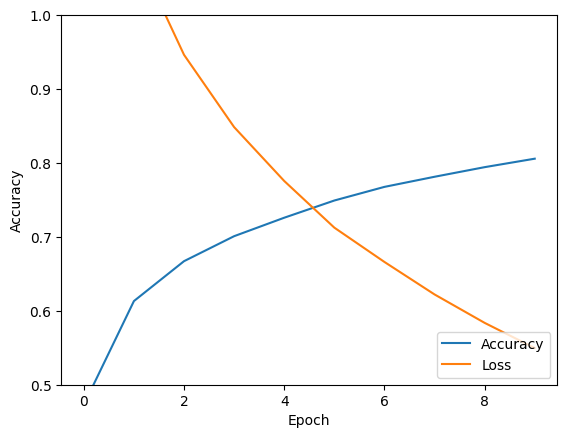

In [23]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['loss'], label = 'Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
[]

### Predict

In [24]:
pred_value = cnn.predict(x_test)
pred_value[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[1.8427447e-04, 1.7354863e-05, 1.7822771e-04, 9.8100400e-01,
        2.5627174e-04, 9.3099475e-03, 6.0392325e-03, 7.4598822e-04,
        2.2307902e-03, 3.3882610e-05],
       [3.3172761e-05, 9.8873721e-03, 5.9698124e-10, 1.5597799e-10,
        3.2884889e-11, 2.6267408e-12, 1.3734849e-10, 1.4525434e-11,
        9.9007058e-01, 8.8716133e-06],
       [1.0216882e-01, 6.8279980e-03, 1.3558611e-05, 6.2109866e-05,
        9.9414603e-05, 6.8276527e-06, 2.6377224e-06, 1.5704904e-04,
        8.8817722e-01, 2.4842336e-03],
       [9.7618937e-01, 8.0958504e-05, 1.8768564e-04, 5.5792229e-05,
        9.0970891e-05, 1.5790191e-06, 1.0029354e-06, 3.7854591e-07,
        2.3209017e-02, 1.8322638e-04],
       [1.3188990e-09, 8.1380414e-08, 8.6213631e-04, 6.4239996e-03,
        3.3224877e-03, 1.0600974e-04, 9.8928493e-01, 1.2326150e-07,
        1.3380401e-08, 2.6476562e-07]], dtype=float32)

argmax() returns index of max element from array

In [25]:
#Example
np.argmax([5, 3, 12, 4])

np.int64(2)

In [26]:
y_classes = [np.argmax(element) for element in pred_value]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

```python
[np.argmax(element) for element in pred_value]
```
returns a list of indices having `max` probability value of each element from predicted values `pred_value` of `x_test`

In [27]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

Let us test random examples from test data

# randomly picking any element from test dataset
import random
n = random.randint(0,9999)
#actual value
show_image(x_test, y_test, n)
plt.show()
#prediction
print('Prediction : ', classes[y_classes[n]] )  


### Saving model

In [31]:
cnn_img_model = r"./cnn_cifar10_model.keras" # Changed filepath to include a proper extension
cnn.save(cnn_img_model)

Model gets saved on local system and can be used by simply importing it as follows

In [32]:
restored_keras_model = keras.models.load_model(cnn_img_model)

In [33]:
restored_keras_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


array([[1.8427447e-04, 1.7354863e-05, 1.7822771e-04, ..., 7.4598822e-04,
        2.2307902e-03, 3.3882610e-05],
       [3.3172761e-05, 9.8873721e-03, 5.9698124e-10, ..., 1.4525434e-11,
        9.9007058e-01, 8.8716133e-06],
       [1.0216882e-01, 6.8279980e-03, 1.3558611e-05, ..., 1.5704904e-04,
        8.8817722e-01, 2.4842336e-03],
       ...,
       [2.9809019e-07, 1.4069842e-09, 6.8958879e-02, ..., 1.0432116e-03,
        2.5344781e-07, 2.1188880e-09],
       [6.7421404e-04, 9.6774149e-01, 2.4775940e-03, ..., 1.6579866e-05,
        4.3636269e-04, 1.3712127e-04],
       [1.2405631e-07, 6.2548162e-09, 2.2683129e-05, ..., 9.8773479e-01,
        2.0418803e-10, 2.0868018e-09]], dtype=float32)

### Summary

In this tutorial, you discovered how to develop a convolutional neural network model from scratch for object photo classification.<br>
This model gives accuracy of `72%` which is good but can be improved.Try different combinations and play with model. It's Fun.<br>  
In my following notebooks I'll introduce you with how to explore extensions to a baseline model to improve learning and model capacity.<br>
Happy Learning.😉